In [1]:
import sys
sys.path.insert(0,'../g3algo/')
from center_binned_stats import center_binned_stats as cbs
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('TkAgg')
import matplotlib.pyplot as plt
from smoothedbootstrap import smoothedbootstrap as sbs

goals
- validate ECO HI inventory (relation matches for RESOLVE and ECO given systematic errors)
- measure shape and scatter of the relation
- validate group finder
    - show matches FoF
- compare with literature
    - possibly validate group finder, otherwise explain discrepancy

need to do:
- decide bins for HIHM relation
- for each bin and for each of RESOLVE and ECO:
    - get median group HI value
    - get statistical error on it from bootstrapping
    - estimate systematic error from ECO (for resolve) or from mocks (ECO)
- output all that file
- show plot with scatter
- show plot with median relation + statistical error (bootstrap) + systematic error (cosmic var)
- show plot comparing to previous results

## Compute $M_{\rm HI\,grp}-M_{\rm halo}$ Relation for RESOLVE

In [2]:
resolve=pd.read_csv("../resolve_and_eco/RESOLVEdata_G3catalog_luminosity.csv")
resolve=resolve[(resolve.g3grpcz_l>4500)&(resolve.g3grpcz_l<7000)&(resolve.fl_insample==1)&(resolve.g3fc_l==1)]
eco=pd.read_csv("../resolve_and_eco/ECOdata_G3catalog_luminosity.csv")
eco=eco[(eco.g3grpcz_l>3000)&(eco.g3grpcz_l<7000)&(eco.absrmag<-17.33)&(eco.g3fc_l==1)&(eco.resname=='notinresolve')]

In [3]:
binvalues = [11,11.1,11.2,11.3,11.4,11.5,11.6,11.7,11.95,12.2,12.45,12.7,12.95,13.3,14.75]
binvalues = [11,11.15,11.3,11.45,11.6,11.75,12.,12.25,12.5,12.75,12.95,13.3,14.75]
#binvalues = [11,11.15,11.3,11.45,11.6,11.75,12.,12.25,12.5,12.75,12.95,13.3,13.8,14.75]

In [4]:
resgrpmhi = resolve.g3grpmhi_l.to_numpy()
reslogmh = resolve.g3logmh_l.to_numpy()
dyn=resolve.g3logmhdyn_l.to_numpy()
gN=(resolve.g3grpngi_l+resolve.g3grpndw_l).to_numpy()
reslogmh[gN>7]=dyn[gN>7]
resfrac = np.log10(10**resgrpmhi / 10**reslogmh)

In [5]:
# medians
resmediangrpmhi,bincenters,_,_=cbs(reslogmh,resgrpmhi,'median',bins=binvalues)
resmedianfrac,bincenters,_,_=cbs(reslogmh,resfrac,'median',bins=binvalues)
# statistical error on median
resmediangrpmhi_m1sig = np.zeros_like(resmediangrpmhi)
resmediangrpmhi_p1sig = np.zeros_like(resmediangrpmhi)
resmedianfrac_m1sig = np.zeros_like(resmedianfrac)
resmedianfrac_p1sig = np.zeros_like(resmedianfrac)
for ii in range(0,len(binvalues)-1):
    datasel = np.where((reslogmh>binvalues[ii])&(reslogmh<binvalues[ii+1]))
    dist_of_medians = sbs(resgrpmhi[datasel], 5000, lambda x: np.median(x,axis=1))
    ptiles = np.percentile(dist_of_medians, (16,84))
    resmediangrpmhi_m1sig[ii]=ptiles[0]
    resmediangrpmhi_p1sig[ii]=ptiles[1]
    dist_of_medians2 = sbs(resfrac[datasel],5000,lambda x:np.median(x,axis=1))
    ptiles2 = np.percentile(dist_of_medians2, (16,84))
    resmedianfrac_m1sig[ii]=ptiles2[0]
    resmedianfrac_p1sig[ii]=ptiles2[1]
resmediangrpmhi_m1sig =  resmediangrpmhi - resmediangrpmhi_m1sig
resmediangrpmhi_p1sig = -resmediangrpmhi + resmediangrpmhi_p1sig
resmedianfrac_m1sig = resmedianfrac - resmedianfrac_m1sig
resmedianfrac_p1sig = -resmedianfrac + resmedianfrac_p1sig

        Use sklearn.utils.check_random_state instead. [smoothedbootstrap]


Next we need to estimate the systematic error on each bin's $M_{\rm HI,\,grp}$ median for RESOLVE. This can be computed by breaking up ECO into many RESOLVE-sized chunks and looking at the spread in the distribution of $M_{\rm HI\,grp}$ values from the chunks.

First note that, according to E16, ECO's volume (no buffer) is 151829 (Mpc/h)$^3$ and the sum of RESOLVE's volume (A and B) = 13172.384 (Mpc/h)$^3$ + 4709.837 (Mpc/h)$^3$ = 17882 (Mpc/h)$^3$. That means RESOLVE can fit into ECO 10.7 times.

To split it into 10 RESOLVE-sized chunks, we can break up ECO into 5 10-degree chunks along its declination range and 2 53.5-degree chunks along its RA range.

In [6]:
ecochunks=[]
chunkRAlimits=[130,183.5,237]
chunkDeclimits=[-1,10,20,30,40,50]
chunkRAranges=[]
chunkDecranges=[]
for ii in range(0,len(chunkRAlimits)-1):
    for jj in range(0,len(chunkDeclimits)-1):
        chunkRAranges.append((chunkRAlimits[ii],chunkRAlimits[ii+1]))
        chunkDecranges.append((chunkDeclimits[jj],chunkDeclimits[jj+1]))
for ii in range(0,(len(chunkRAlimits)-1)*(len(chunkDeclimits)-1)):
    tmp=eco[(eco.g3grpcz_l>3000)&(eco.g3grpcz_l<7000)&(eco.radeg>chunkRAranges[ii][0])\
            &(eco.radeg<chunkRAranges[ii][1])\
            &(eco.dedeg>chunkDecranges[ii][0])\
            &(eco.dedeg<chunkDecranges[ii][1])]
    ecochunks.append(tmp)
assert len(ecochunks)==(len(chunkRAlimits)-1)*(len(chunkDeclimits)-1)

Now what we want to do is process each chunk. For each bin, we need to go through each chunk and get the distribution of medians. The 1sigma confidence interval on the median of each distribution can be the estimate of the systematic error.

In [7]:
mediangrpmhi_from_chk=[]
medianfrac_from_chk=[]
for chk in ecochunks:
    tmp,_,_,_ = cbs(chk.g3logmh_l.to_numpy(),chk.g3grpmhi_l.to_numpy(),'median',bins=binvalues)
    mediangrpmhi_from_chk.append(tmp)
    tmp2,_,_,_= cbs(chk.g3logmh_l.to_numpy(),np.log10(10**chk.g3grpmhi_l.to_numpy()/10**chk.g3logmh_l.to_numpy()),'median',bins=binvalues)
    medianfrac_from_chk.append(tmp2)
mediangrpmhi_from_chk=np.array(mediangrpmhi_from_chk)
medianfrac_from_chk=np.array(medianfrac_from_chk)

In [8]:
resmediangrpmhi_msys = np.nanmedian(mediangrpmhi_from_chk,axis=0)-np.nanpercentile(mediangrpmhi_from_chk,16,axis=0)
resmediangrpmhi_psys = -1*np.nanmedian(mediangrpmhi_from_chk,axis=0)+np.nanpercentile(mediangrpmhi_from_chk,84,axis=0)

In [9]:
resmedianfrac_msys = np.nanmedian(medianfrac_from_chk,axis=0)-np.nanpercentile(medianfrac_from_chk,16,axis=0)
resmedianfrac_psys = -1*np.nanmedian(medianfrac_from_chk,axis=0)+np.nanpercentile(medianfrac_from_chk,84,axis=0)

In [10]:
resmedianfrac_msys, resmedianfrac_psys

(array([0.05215241, 0.01239145, 0.06976437, 0.06932096, 0.02797894,
        0.08993917, 0.11776526, 0.16846563, 0.19150371, 0.18551239,
        0.11100341, 0.19681259]),
 array([0.10889009, 0.07547246, 0.03948014, 0.0530794 , 0.08869825,
        0.10668233, 0.06824028, 0.19560113, 0.19845512, 0.21193357,
        0.1704119 , 0.22778461]))

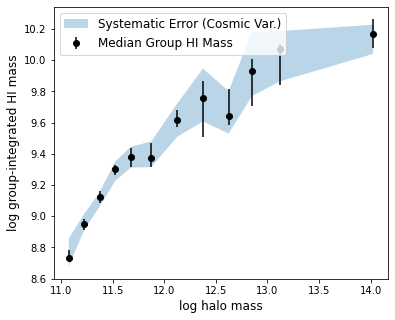

In [11]:
%matplotlib inline
plt.figure(figsize=(6,5))
plt.fill_between(bincenters,resmediangrpmhi-resmediangrpmhi_msys,resmediangrpmhi+resmediangrpmhi_psys, alpha=0.3,label='Systematic Error (Cosmic Var.)')
plt.errorbar(bincenters,resmediangrpmhi,yerr=[resmediangrpmhi_m1sig,resmediangrpmhi_p1sig],ls='none', marker='o',color='k', label='Median Group HI Mass')
plt.xlabel("log halo mass",fontsize=12)
plt.ylabel("log group-integrated HI mass",fontsize=12)
plt.legend(loc='upper left',fontsize=12)
plt.show()

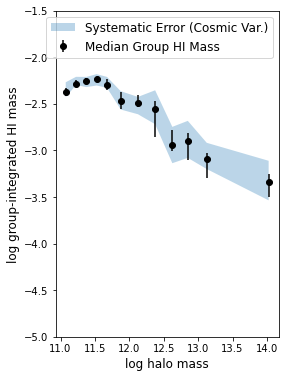

In [12]:
plt.figure(figsize=(4,6))
plt.fill_between(bincenters,resmedianfrac-resmedianfrac_msys,resmedianfrac+resmedianfrac_psys, alpha=0.3,label='Systematic Error (Cosmic Var.)')
plt.errorbar(bincenters,resmedianfrac,yerr=[resmedianfrac_m1sig,resmedianfrac_p1sig],ls='none', marker='o',color='k', label='Median Group HI Mass')
plt.xlabel("log halo mass",fontsize=12)
plt.ylabel("log group-integrated HI mass",fontsize=12)
plt.legend(loc='best',fontsize=12)
plt.ylim(-5,-1.5)
plt.show()

## Compute $M_{\rm HI\,grp}-M_{\rm halo}$ Relation for ECO

Now we are going to do a similar process but for ECO (excluding RESOLVE-A). This time, we'll use mocks to estimate systematic errors from cosmic variance.

In [13]:
ecogrpmhi = eco.g3grpmhi_l.to_numpy()
ecologmh = eco.g3logmh_l.to_numpy()
dyn=eco.g3logmhdyn_l.to_numpy()
gN=(eco.g3grpngi_l+eco.g3grpndw_l).to_numpy()
ecologmh[gN>7]=dyn[gN>7]
ecofrac = np.log10(10**ecogrpmhi / 10**ecologmh)

In [14]:
# medians
ecomediangrpmhi,bincenters,_,_=cbs(ecologmh,ecogrpmhi,np.median,bins=binvalues)
# statistical error on median
ecomediangrpmhi_m1sig = np.zeros_like(ecomediangrpmhi)
ecomediangrpmhi_p1sig = np.zeros_like(ecomediangrpmhi)
for ii in range(0,len(binvalues)-1):
    datasel = np.where((ecologmh>binvalues[ii])&(ecologmh<binvalues[ii+1]))
    dist_of_medians = sbs(ecogrpmhi[datasel], 5000, lambda x: np.median(x,axis=1))
    ptiles = np.percentile(dist_of_medians, (16,84))
    ecomediangrpmhi_m1sig[ii]=ptiles[0]
    ecomediangrpmhi_p1sig[ii]=ptiles[1]
ecomediangrpmhi_m1sig =  ecomediangrpmhi - ecomediangrpmhi_m1sig
ecomediangrpmhi_p1sig = -ecomediangrpmhi + ecomediangrpmhi_p1sig

        Use sklearn.utils.check_random_state instead. [smoothedbootstrap]


In [15]:
# medians
ecomedianfrac,bincenters,_,_=cbs(ecologmh,ecofrac,'median',bins=binvalues)
# statistical error on median
ecomedianfrac_m1sig = np.zeros_like(ecomedianfrac)
ecomedianfrac_p1sig = np.zeros_like(ecomedianfrac)
for ii in range(0,len(binvalues)-1):
    datasel = np.where((ecologmh>binvalues[ii])&(ecologmh<binvalues[ii+1]))
    dist_of_medians = sbs(ecofrac[datasel], 5000, lambda x: np.median(x,axis=1))
    ptiles = np.percentile(dist_of_medians, (16,84))
    ecomedianfrac_m1sig[ii]=ptiles[0]
    ecomedianfrac_p1sig[ii]=ptiles[1]
ecomedianfrac_m1sig =  ecomedianfrac - ecomedianfrac_m1sig
ecomedianfrac_p1sig = -ecomedianfrac + ecomedianfrac_p1sig

Before moving on, let's quickly check our answer for the most massive bin. We can compare our answer with a manual bootstrapping from np.random.choice.

In [16]:
# 13.3,14.75
tmp = ecogrpmhi[np.where(np.logical_and(ecologmh>binvalues[-2],ecologmh<binvalues[-1]))]
newmedians=[]
for ii in range(0,5000):
    newmedians.append(np.median(np.random.choice(tmp,size=len(tmp))))
print('these should be similar (order-of-magnitude): ')
print(ecomediangrpmhi_p1sig[-1], np.std(newmedians))

these should be similar (order-of-magnitude): 
0.02134168600550268 0.02401293505239912


In [17]:
# 13.3,14.75
tmp = ecofrac[np.where(np.logical_and(ecologmh>binvalues[-2],ecologmh<binvalues[-1]))]
newmedians=[]
for ii in range(0,5000):
    newmedians.append(np.median(np.random.choice(tmp,size=len(tmp))))
print('these should be similar (order-of-magnitude): ')
print(ecomedianfrac_p1sig[-1], np.std(newmedians))

these should be similar (order-of-magnitude): 
0.04357207080905123 0.05406602682521177


With that checked, we can move on to computing systematic errors for group $M_{\rm HI}$ for ECO. The errors will be computed from the mock catalogs.

As we did before using chunks, we will go through each mock catalog and attain the median $M_{\rm HI\,grp}$ for every bin in accordance with `binvalues`. For each of these halo mass bins, ECO's systematic error will be the 1$\sigma$ confidence interval on the distribution of median values.

**NOTE:** Make sure group finding on mocks is up-to-date before running the below cells.

In [18]:
import os

In [19]:
mocks = [pd.read_csv('../halobiasgroupcats/fiducial/'+str(x)) for x in os.listdir('../halobiasgroupcats/fiducial/')]

Now we've loaded up the mocks that we need to compute our systematic cosmic variance error. The following cell iterates through each of these mocks and computes the median group HI mass in each of bins corresponding to `binvalues`.

In [20]:
mockgrpmhimedians=[]
mockfracmedians=[]
for catl in mocks:
    tmp=catl[catl.g3grp_l>0]
    tmp=tmp.groupby('g3grp_l').first()
    logmh=tmp.g3logmh_l.to_numpy()
    mhigrp=(tmp.g3grpmhi_l.to_numpy())
    frac = np.log10(10**mhigrp / 10**logmh)
    median,_,_,_=cbs(logmh,mhigrp,'median',bins=binvalues)
    mockgrpmhimedians.append(median)
    median,_,_,_=cbs(logmh,frac,'median',bins=binvalues)
    mockfracmedians.append(median)
mockgrpmhimedians=np.array(mockgrpmhimedians)
mockfracmedians=np.array(mockfracmedians)

In [21]:
np.nanmedian(mockgrpmhimedians,axis=0).shape

(12,)

In [22]:
ecomediangrpmhi_msys = np.nanmedian(mockgrpmhimedians,axis=0)-np.nanpercentile(mockgrpmhimedians,16,axis=0)
ecomediangrpmhi_psys = -1*np.nanmedian(mockgrpmhimedians,axis=0)+np.nanpercentile(mockgrpmhimedians,84,axis=0)

In [23]:
ecomedianfrac_msys = np.nanmedian(mockfracmedians,axis=0)-np.nanpercentile(mockfracmedians,16,axis=0)
ecomedianfrac_psys = -1*np.nanmedian(mockfracmedians,axis=0)+np.nanpercentile(mockfracmedians,84,axis=0)

In [24]:
ecomediangrpmhi_msys, ecomediangrpmhi_psys

(array([0.03760014, 0.09759978, 0.09230516, 0.08999995, 0.08279986,
        0.03452088, 0.12817503, 0.05296636, 0.0913943 , 0.10605292,
        0.13845421, 0.06383588]),
 array([0.13760022, 0.11520022, 0.11809467, 0.10999995, 0.0875996 ,
        0.05727584, 0.12222354, 0.0898558 , 0.10949111, 0.08160926,
        0.05856542, 0.12832107]))

In [25]:
ecomedianfrac_msys, ecomedianfrac_psys

(array([0.07536049, 0.10009011, 0.0886894 , 0.08169199, 0.1045211 ,
        0.02830632, 0.11483524, 0.05953176, 0.07097311, 0.09334733,
        0.16559753, 0.12387993]),
 array([0.13897944, 0.11111163, 0.1250592 , 0.11303744, 0.07302963,
        0.02425982, 0.13884072, 0.07930232, 0.15752098, 0.09230471,
        0.08700254, 0.08774853]))

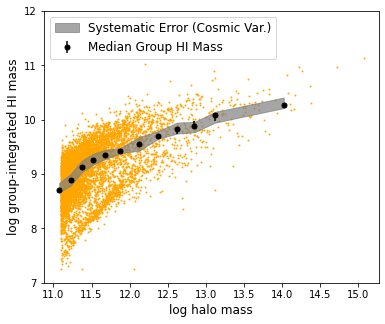

In [26]:
plt.figure(figsize=(6,5))
plt.plot(ecologmh,ecogrpmhi,'.', color='orange',alpha=0.9, zorder=0, markersize=2)
plt.errorbar(bincenters,ecomediangrpmhi,yerr=[ecomediangrpmhi_m1sig,ecomediangrpmhi_p1sig],ls='none', marker='o', markersize=5, color='k', label='Median Group HI Mass')
plt.fill_between(bincenters,ecomediangrpmhi-ecomediangrpmhi_msys,ecomediangrpmhi+ecomediangrpmhi_psys, color='gray', alpha=0.7,label='Systematic Error (Cosmic Var.)')
plt.xlabel("log halo mass",fontsize=12)
plt.ylabel("log group-integrated HI mass",fontsize=12)
plt.legend(loc='upper left',fontsize=12)
plt.ylim(7,12)
plt.show()

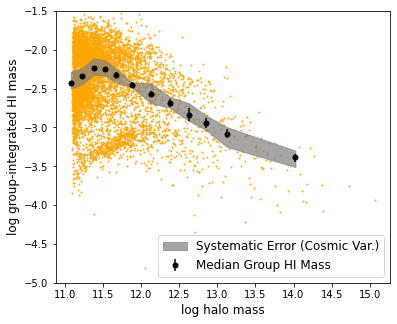

In [27]:
plt.figure(figsize=(6,5))
plt.plot(ecologmh,ecofrac,'.', color='orange',alpha=0.9, zorder=0, markersize=2)
plt.errorbar(bincenters,ecomedianfrac,yerr=[ecomedianfrac_m1sig,ecomedianfrac_p1sig],ls='none', marker='o', markersize=5, color='k', label='Median Group HI Mass')
plt.fill_between(bincenters,ecomedianfrac-ecomedianfrac_msys,ecomedianfrac+ecomedianfrac_psys, color='gray', alpha=0.7,label='Systematic Error (Cosmic Var.)')
plt.xlabel("log halo mass",fontsize=12)
plt.ylabel("log group-integrated HI mass",fontsize=12)
plt.legend(loc='lower right',fontsize=12)
plt.ylim(-5,-1.5)
plt.show()

In [28]:
# get Mstar, Mbary medians also
ecogrpmstar = eco.g3grplogS_l.to_numpy()
ecogrpmbary = eco.g3grplogB_l.to_numpy()
ecomediangrpmstar,_,_,_=cbs(ecologmh,ecogrpmstar,'median',bins=binvalues)
ecomediangrpmbary,_,_,_=cbs(ecologmh,ecogrpmbary,'median',bins=binvalues)
ecogrpstellarfrac=np.log10(10**ecomediangrpmstar / 10**bincenters)
ecogrpbaryonicfrac=np.log10(10**ecomediangrpmbary / 10**bincenters)

In [29]:
outputdata = np.array([
    bincenters,
    resmediangrpmhi,
    resmediangrpmhi_m1sig,
    resmediangrpmhi_p1sig,
    resmediangrpmhi_msys,
    resmediangrpmhi_psys,
    ecomediangrpmhi,
    ecomediangrpmhi_m1sig,
    ecomediangrpmhi_p1sig,
    ecomediangrpmhi_msys,
    ecomediangrpmhi_psys,
    ecomediangrpmstar,
    ecomediangrpmbary,
])
pd.DataFrame(outputdata.T, columns=['logmh','resmhigrp','resmhigrp_staterrlo','resmhigrp_staterrhi',\
            'resmhigrp_syserrlo','resmhigrp_syserrhi','ecomhigrp','ecomhigrp_staterrlo','ecomhigrp_staterrhi',\
            'ecomhigrp_syserrlo','ecomhigrp_syserrhi','ecogrpmstar','ecogrpmbary']).to_csv("resolve_eco_hihm.csv",index=False)

In [30]:
outputdata = np.array([
    bincenters,
    resmedianfrac,
    resmedianfrac_m1sig,
    resmedianfrac_p1sig,
    resmedianfrac_msys,
    resmedianfrac_psys,
    ecomedianfrac,
    ecomedianfrac_m1sig,
    ecomedianfrac_p1sig,
    ecomedianfrac_msys,
    ecomedianfrac_psys,
    ecogrpstellarfrac,
    ecogrpbaryonicfrac,
])
pd.DataFrame(outputdata.T, columns=['logmh','resfrac','resfrac_staterrlo','resfrac_staterrhi',\
            'resfrac_syserrlo','resfrac_syserrhi','ecofrac','ecofrac_staterrlo','ecofrac_staterrhi',\
            'ecofrac_syserrlo','ecofrac_syserrhi','ecostellarfrac','ecobaryfrac']).to_csv("resolve_eco_mhiovermhalo.csv",index=False)

In [31]:
%reset -f

# Paper Plots

In [32]:
def hihalomodel(Mh, M0, Mmin, alpha):
    return M0*((Mh/Mmin)**alpha)*np.exp(-1*Mmin/Mh)
def hihalomodel2(params, Mh):
    return params[0]*((Mh/params[1])**params[2])*np.exp(-1*params[1]/Mh)

In [33]:
import sys
sys.path.insert(0,'../g3algo/')
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('TkAgg')
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, AutoLocator
from matplotlib import rcParams
from scipy.optimize import curve_fit
from scipy.stats import chisquare
import foftools as fof
import iterativecombination as ic
from scipy import odr
rcParams['axes.labelsize'] = 9
rcParams['xtick.labelsize'] = 9
rcParams['ytick.labelsize'] = 9
rcParams['legend.fontsize'] = 9
rcParams['font.family'] = 'sans-serif'
rcParams['grid.color'] = 'k'
rcParams['grid.linewidth'] = 0.2
my_locator = MaxNLocator(6)
singlecolsize = (3.3522420091324205, 2.0717995001590714)
doublecolsize = (7.500005949910059, 4.3880449973709)

In [34]:
resolve=pd.read_csv("../resolve_and_eco/RESOLVEdata_G3catalog_luminosity.csv")
resolve=resolve[(resolve.g3grpcz_l>4500)&(resolve.g3grpcz_l<7000)&(resolve.fl_insample==1)&(resolve.g3fc_l==1)]
eco=pd.read_csv("../resolve_and_eco/ECOdata_G3catalog_luminosity.csv")
eco=eco[(eco.g3grpcz_l>3000)&(eco.g3grpcz_l<7000)&(eco.absrmag<-17.33)&(eco.g3fc_l==1)&(eco.resname=='notinresolve')]
binnedhihm = pd.read_csv("resolve_eco_hihm.csv")
binnedfrac = pd.read_csv("resolve_eco_mhiovermhalo.csv")

## (1) The Shape of the RESOLVE and ECO HI-halo Mass Relation

In [35]:
%matplotlib inline
resolveshadecolor='#7AA8E7'
resolvemarkercolor='#3D5473'
ecoshadecolor='#E7B97A'
ecomarkercolor='#a66d1e'

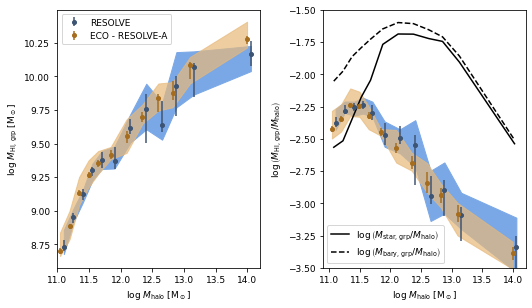

In [36]:
hoffset = 0.03
fig,axs=plt.subplots(figsize=doublecolsize,ncols=2)
axs[0].errorbar(binnedhihm.logmh+hoffset,binnedhihm.resmhigrp,\
                yerr=[binnedhihm.resmhigrp_staterrlo,binnedhihm.resmhigrp_staterrhi],\
                color=resolvemarkercolor,ls='none',markersize=4, marker='o', label='RESOLVE')
axs[0].fill_between(binnedhihm.logmh+hoffset,binnedhihm.resmhigrp-binnedhihm.resmhigrp_syserrlo,\
                    binnedhihm.resmhigrp_syserrhi+binnedhihm.resmhigrp,\
                   color=resolveshadecolor, alpha=1)
axs[0].errorbar(binnedhihm.logmh-hoffset,binnedhihm.ecomhigrp,\
                yerr=[binnedhihm.ecomhigrp_staterrlo,binnedhihm.ecomhigrp_staterrhi],\
                color=ecomarkercolor,ls='none',markersize=4, marker='o', label='ECO - RESOLVE-A')
axs[0].fill_between(binnedhihm.logmh-hoffset,binnedhihm.ecomhigrp-binnedhihm.ecomhigrp_syserrlo,\
                    binnedhihm.ecomhigrp_syserrhi+binnedhihm.ecomhigrp,\
                   color=ecoshadecolor, alpha=0.7)
axs[0].legend(loc='best')

axs[1].plot(binnedfrac.logmh,binnedfrac.ecostellarfrac,'k-',label=r"$\log \left( M_{\rm star,\, grp} / M_{\rm halo}  \right)$")
axs[1].plot(binnedfrac.logmh,binnedfrac.ecobaryfrac,'k--',label=r"$\log \left( M_{\rm bary,\, grp} / M_{\rm halo}  \right)$")
axs[1].errorbar(binnedfrac.logmh+hoffset,binnedfrac.resfrac,\
                yerr=[binnedfrac.resfrac_staterrlo,binnedfrac.resfrac_staterrhi],\
                color=resolvemarkercolor,ls='none',markersize=4, marker='o')
axs[1].fill_between(binnedfrac.logmh+hoffset,binnedfrac.resfrac-binnedfrac.resfrac_syserrlo,\
                    binnedfrac.resfrac_syserrhi+binnedfrac.resfrac,\
                   color=resolveshadecolor, alpha=1)
axs[1].errorbar(binnedfrac.logmh-hoffset,binnedfrac.ecofrac,\
                yerr=[binnedfrac.ecofrac_staterrlo,binnedfrac.ecofrac_staterrhi],\
                color=ecomarkercolor,ls='none',markersize=4, marker='o')
axs[1].fill_between(binnedfrac.logmh-hoffset,binnedfrac.ecofrac-binnedfrac.ecofrac_syserrlo,\
                    binnedfrac.ecofrac_syserrhi+binnedfrac.ecofrac,\
                   color=ecoshadecolor, alpha=0.7)
axs[1].set_ylim(-3.5,-1.5)
axs[1].legend(loc='best')


axs[0].set_ylabel(r"log $M_{\rm HI,\, grp}$ [$\rm M_\odot$]")
axs[0].set_xlabel(r"log $M_{\rm halo}$ [$\rm M_\odot$]")
axs[1].set_xlabel(r"log $M_{\rm halo}$ [$\rm M_\odot$]")
axs[1].set_ylabel(r"$\log \left( M_{\rm HI,\, grp} / M_{\rm halo}  \right)$")
axs[0].set_xlim(11,14.2)
#axs[0].xaxis.set_minor_locator(MaxNLocator(5))
plt.tight_layout()
plt.savefig("../figures/RESOLVE_ECO_HIHMshape.pdf")
plt.show()

### The Best-Fitting Halo Model

In [37]:
staterr = (binnedhihm.ecomhigrp_staterrlo+binnedhihm.ecomhigrp_staterrhi)/2.
syserr = (binnedhihm.ecomhigrp_syserrlo+binnedhihm.ecomhigrp_syserrhi)/2.
comberr = staterr+syserr
comberrlin = 10**binnedhihm.ecomhigrp-10**(binnedhihm.ecomhigrp-comberr)
popthi,pcov=curve_fit(hihalomodel, 10**binnedhihm.logmh, 10**binnedhihm.ecomhigrp,\
                     sigma=comberrlin, absolute_sigma=True, p0=[1.689e9, 1.2698e11, 3.686e-1], maxfev=2000)
perrhi=np.sqrt(np.diagonal(pcov))

<IPython.core.display.Javascript object>


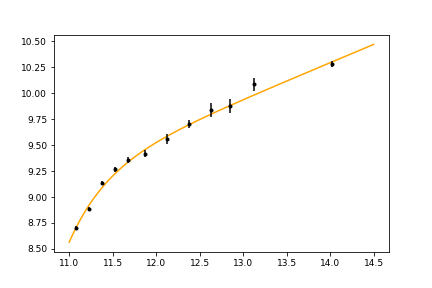

In [38]:
%matplotlib notebook
plt.figure()
tx = np.linspace(11,14.5,int(5e5))
plt.plot(tx, np.log10(hihalomodel(10**tx,*popthi)),color='orange')
plt.errorbar(binnedhihm.logmh,binnedhihm.ecomhigrp,yerr=staterr,ls='None',color='k',marker='.')
plt.show()

In [39]:
print("best fitting logM0: ", np.log10(popthi[0]), " +/- ", np.log10(popthi[0])-np.log10(perrhi[0]))
print("best fitting logMmin: ", np.log10(popthi[1]), " +/- ", np.log10(popthi[1])-np.log10(perrhi[1]))
print("best fitting alpha: ", popthi[2], " +/- ", perrhi[2])

best fitting logM0:  9.308719827280443  +/-  0.5274927679818653
best fitting logMmin:  11.191995639682661  +/-  0.5782294437546547
best fitting alpha:  0.35122830497562035  +/-  0.057456327920326844


In [40]:
# Now fit FOF
ecofof=pd.read_csv("../resolve_and_eco/ECOdata_G3catalog_luminosity.csv")
fofmhigrp = ic.get_int_mass(np.log10(10**ecofof.logmgas/1.4),ecofof.grp)
ecofof.loc[:,'fofmhigrp']=fofmhigrp
ecofof=ecofof[(ecofof.grpcz>3000)&(ecofof.grpcz<7000)&(ecofof.absrmag<-17.33)&(ecofof.fc==1)&(ecofof.resname=='notinresolve')]
fofmhigrp = ecofof.fofmhigrp.to_numpy()
foflogmh = ecofof.logmh.to_numpy()

In [41]:
from center_binned_stats import center_binned_stats as cbs

<IPython.core.display.Javascript object>


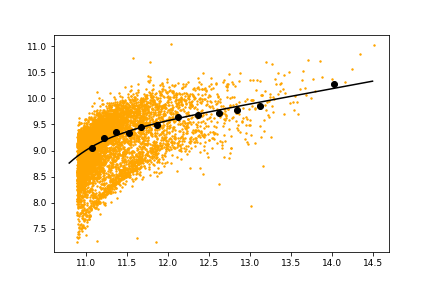

In [42]:
binvalues = [11,11.15,11.3,11.45,11.6,11.75,12.,12.25,12.5,12.75,12.95,13.3,13.8,14.75]
binvalues = [11,11.15,11.3,11.45,11.6,11.75,12.,12.25,12.5,12.75,12.95,13.3,14.75]
median,bc,_,_=cbs(foflogmh,fofmhigrp,'median',bins=binvalues)
poptfof,pcov=curve_fit(hihalomodel,10**bc,10**median,p0=[10**9.4,10**11.03,0.3],maxfev=2000,sigma=comberrlin)
perrfof=np.sqrt(np.diagonal(pcov))

plt.figure()
plt.scatter(foflogmh,fofmhigrp,s=2,color='orange')
plt.plot(bc,median,'ko')
foftx=np.linspace(10.8,14.5,10000)
plt.plot(foftx, np.log10(hihalomodel(10**foftx,*poptfof)),color='k')

plt.show()

In [43]:
print("best fitting logM0: ", np.log10(poptfof[0]), " +/- ", np.log10(poptfof[0])-np.log10(perrfof[0]))
print("best fitting logMmin: ", np.log10(poptfof[1]), " +/- ", np.log10(poptfof[1])-np.log10(perrfof[1]))
print("best fitting alpha: ", poptfof[2], " +/- ", perrfof[2])

best fitting logM0:  9.269970599328076  +/-  0.6466559130578364
best fitting logMmin:  10.855693603187921  +/-  0.5719604516823864
best fitting alpha:  0.29024297906997004  +/-  0.04077971226270544


In [44]:
print("chi2: ")
#zscores = (binnedhihm.ecomhigrp - np.log10(hihalomodel(10**binnedhihm.logmh,*popthi))) / (staterr+syserr)
zscores = (10**median - hihalomodel(10**bc,*poptfof)) / comberrlin
chi2 = np.sum(zscores**2.)
dof = len(binnedhihm)-1
chi2dof = chi2 / dof
sigma = np.sqrt(2./dof)
print(chi2dof)
print((chi2dof-1)/sigma)

chi2: 
0.36758745026589845
-1.483138894991474


### Where does the group-integrated HI mass fraction peak?

<IPython.core.display.Javascript object>


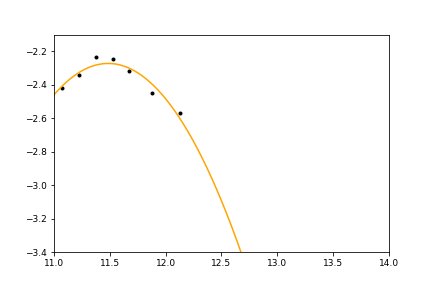

11.485148514851485


In [45]:
plt.figure()
stopindex=7
plt.plot(binnedfrac.logmh[0:stopindex],binnedfrac.ecofrac[0:stopindex],'k.')
parab = lambda x,a,b,c: a*(x**2)+b*x+c
popt,_=curve_fit(parab,binnedfrac.logmh[0:stopindex],binnedfrac.ecofrac[0:stopindex])
tx=np.linspace(11,14,10000)
modelvals = parab(tx,*popt)
plt.plot(tx,modelvals,color='orange')
plt.xlim(11,14)
plt.ylim(-3.4,-2.1)

print(tx[np.argmax(modelvals)])
plt.show()

## (2) The Scatter of the RESOLVE and ECO HI-Halo Mass Relation

<IPython.core.display.Javascript object>


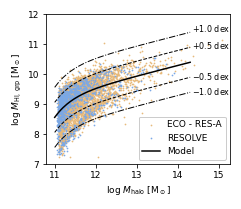

In [46]:
ecologmh=eco.g3logmh_l.to_numpy()
dyn=eco.g3logmhdyn_l.to_numpy()
gN=(eco.g3grpngi_l+eco.g3grpndw_l).to_numpy()
ecologmh[gN>7]=dyn[gN>7]
ecogrpmhi=eco.g3grpmhi_l.to_numpy()
resolvelogmh=resolve.g3logmh_l.to_numpy()
dyn=resolve.g3logmhdyn_l.to_numpy()
gN=(resolve.g3grpngi_l+resolve.g3grpndw_l).to_numpy()
resolvelogmh[gN>7]=dyn[gN>7]
resolvegrpmhi=resolve.g3grpmhi_l.to_numpy()

plt.figure(figsize=(singlecolsize[0],1.4*singlecolsize[1]))
plt.scatter(ecologmh,ecogrpmhi,color=ecoshadecolor,s=0.5,label='ECO - RES-A')
plt.scatter(resolvelogmh,resolvegrpmhi,color=resolveshadecolor,s=0.5, label='RESOLVE')
tx=np.linspace(10**11.,10**14.3,10000)
modelvals=np.log10(hihalomodel(tx,*popthi))
plt.plot(np.log10(tx),modelvals,color='k', label='Model')
plt.plot(np.log10(tx),modelvals-1,color='k',linestyle='-.', linewidth=1)
plt.plot(np.log10(tx),modelvals+1,color='k',linestyle='-.', linewidth=1)
plt.plot(np.log10(tx),modelvals-0.5,color='k',linestyle='--', linewidth=1)
plt.plot(np.log10(tx),modelvals+0.5,color='k',linestyle='--', linewidth=1)
plt.annotate('$+1.0$ dex',xy=(14.35,11.4),fontsize=8)
plt.annotate('$+$0.5 dex',xy=(14.35,10.85),fontsize=8)
plt.annotate('$-$1.0 dex',xy=(14.35,9.3),fontsize=8)
plt.annotate('$-$0.5 dex',xy=(14.35,9.8),fontsize=8)
plt.ylim(7,12)
plt.ylabel(r"log $M_{\rm HI,\, grp}$ [$\rm M_\odot$]")
plt.xlabel(r"log $M_{\rm halo}$ [$\rm M_\odot$]")
plt.legend(loc='lower right', framealpha=1)
plt.tight_layout()
plt.savefig("../figures/test.pdf",dpi=300)
plt.show()

<IPython.core.display.Javascript object>


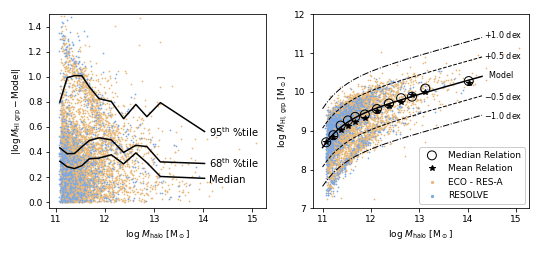

In [67]:
ecologmh=eco.g3logmh_l.to_numpy()
dyn=eco.g3logmhdyn_l.to_numpy()
gN=(eco.g3grpngi_l+eco.g3grpndw_l).to_numpy()
ecologmh[gN>7]=dyn[gN>7]
ecogrpmhi=eco.g3grpmhi_l.to_numpy()
resolvelogmh=resolve.g3logmh_l.to_numpy()
dyn=resolve.g3logmhdyn_l.to_numpy()
gN=(resolve.g3grpngi_l+resolve.g3grpndw_l).to_numpy()
resolvelogmh[gN>7]=dyn[gN>7]
resolvegrpmhi=resolve.g3grpmhi_l.to_numpy()

fig,axs=plt.subplots(ncols=2,figsize=(doublecolsize[0],0.8*doublecolsize[1]))
axs[1].scatter(ecologmh,ecogrpmhi,color=ecoshadecolor,s=0.5)
axs[1].scatter(resolvelogmh,resolvegrpmhi,color=resolveshadecolor,s=0.5)
tx=np.linspace(10**11.,10**14.3,10000)
modelvals=np.log10(hihalomodel(tx,*popthi))
# axs[1].errorbar(binnedhihm.logmh,binnedhihm.ecomhigrp,yerr=[binnedhihm.ecomhigrp_staterrlo,binnedhihm.ecomhigrp_staterrhi],\
#                markeredgecolor='k',markerfacecolor='None',ls='None',marker='o',markersize=5,label='Median')
axs[1].scatter(binnedhihm.logmh,binnedhihm.ecomhigrp,marker='o',facecolor='None',edgecolor='k',label='Median Relation',s=80)
mean,bc,_,_ = cbs(ecologmh,ecogrpmhi,np.average,bins=binvalues)
axs[1].plot(bc,mean,'k*', label='Mean Relation')
axs[1].plot(np.log10(tx),modelvals,color='k')
axs[1].plot(np.log10(tx),modelvals-1,color='k',linestyle='-.', linewidth=1)
axs[1].plot(np.log10(tx),modelvals+1,color='k',linestyle='-.', linewidth=1)
axs[1].plot(np.log10(tx),modelvals-0.5,color='k',linestyle='--', linewidth=1)
axs[1].plot(np.log10(tx),modelvals+0.5,color='k',linestyle='--', linewidth=1)
axs[1].annotate('$+1.0$ dex',xy=(14.35,11.4),fontsize=8)
axs[1].annotate('$+$0.5 dex',xy=(14.35,10.85),fontsize=8)
axs[1].annotate('  Model', xy=(14.35,10.35),fontsize=8)
axs[1].annotate('$-$1.0 dex',xy=(14.35,9.3),fontsize=8)
axs[1].annotate('$-$0.5 dex',xy=(14.35,9.8),fontsize=8)
axs[1].set_ylim(7,12)
axs[1].scatter(12,-99,color=ecoshadecolor,s=5,label='ECO - RES-A')
axs[1].scatter(12,-99,color=resolveshadecolor,s=5,label='RESOLVE')
axs[1].set_ylabel(r"log $M_{\rm HI,\, grp}$ [$\rm M_\odot$]")
axs[1].set_xlabel(r"log $M_{\rm halo}$ [$\rm M_\odot$]")
axs[1].legend(loc='lower right', framealpha=1)

binvalues = [11,11.15,11.3,11.45,11.6,11.75,12.,12.25,12.5,12.75,12.95,13.3,14.75]
residuals=np.abs(ecogrpmhi - np.log10(hihalomodel(10**ecologmh,*popthi)))
resresiduals=np.abs(resolvegrpmhi - np.log10(hihalomodel(10**resolvelogmh,*popthi)))
medresid,bc,_,_=cbs(ecologmh,residuals,'median',bins=binvalues)
axs[0].scatter(ecologmh, residuals,color=ecoshadecolor,s=0.5)
axs[0].scatter(resolvelogmh,resresiduals,color=resolveshadecolor,s=0.5)
axs[0].plot(bc,medresid,'k')
axs[0].annotate("Median",xy=(max(bc)+0.1,medresid[-1]-0.04))
resid95,bc,_,_=cbs(ecologmh,residuals,lambda x:np.nanpercentile(x,95),bins=binvalues)
axs[0].plot(bc,resid95,color='k')
axs[0].annotate(r"95$^{\rm th}$ %tile",xy=(max(bc)+0.1,resid95[-1]-0.04))
resid68,bc,_,_=cbs(ecologmh,residuals,lambda x:np.nanpercentile(x,68),bins=binvalues)
axs[0].plot(bc,resid68,color='k')
axs[0].annotate(r"68$^{\rm th}$ %tile",xy=(max(bc)+0.1,resid68[-1]-0.04))
axs[0].set_ylim(-0.05,1.5)
axs[0].set_ylabel(r"$\left\|\log M_{\rm HI\,\, grp} - {\rm Model}\right\|$")
axs[0].set_xlabel(r"log $M_{\rm halo}$ [$\rm M_\odot$]")
plt.tight_layout()
plt.savefig("../figures/RESOLVE_ECO_HIHMscatter.pdf",dpi=300)
plt.show()

In [68]:
np.max(np.abs(mean - binnedhihm.ecomhigrp))

0.1413282344296274

In [69]:
below_pt5dex_flag = ecogrpmhi < np.log10(hihalomodel(10**ecologmh,*popthi))+0.5
below_pt5dex_percent = np.sum(below_pt5dex_flag)/len(below_pt5dex_flag)
print(below_pt5dex_percent)

above_mpt5dex_flag = (ecogrpmhi > np.log10(hihalomodel(10**ecologmh,*popthi))-0.5)
above_mpt5dex_percent = np.sum(above_mpt5dex_flag)/len(above_mpt5dex_flag)
print(above_mpt5dex_percent)

0.940714163676747
0.8194088501623099


## (3) Comparing to Previous Work

In [70]:
import foftools as fof

<IPython.core.display.Javascript object>


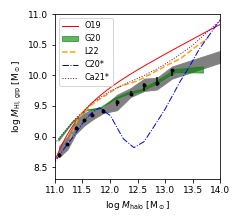

In [85]:
plt.figure(figsize=(singlecolsize[0],singlecolsize[1]*1.5))
plt.plot()
tx=np.linspace(11,15,10000)
#plt.plot(tx,np.log10(hihalomodel(10**tx,*popthi)),color='k',linewidth=1, zorder=98, label='G3')
plt.errorbar(binnedhihm.logmh,binnedhihm.ecomhigrp,yerr=[binnedhihm.ecomhigrp_staterrlo,binnedhihm.ecomhigrp_staterrhi],\
             color='k',ls='None',marker='o',markersize=3)
plt.fill_between(binnedhihm.logmh,binnedhihm.ecomhigrp-binnedhihm.ecomhigrp_syserrlo,binnedhihm.ecomhigrp+binnedhihm.ecomhigrp_syserrhi,\
                color='grey')
# Obuljen 2019
obuljen_alpha = 0.48
obuljen_Mmin = 10**(11.18) / 0.7 / fof.getmhoffset(180,337,1,1,6)
obuljen_M0 = 10**9.44 / 0.7 / fof.getmhoffset(180,337,1,1,6)
obuljen_params = (obuljen_M0, obuljen_Mmin, obuljen_alpha)
plt.plot(tx, np.log10(hihalomodel(10**tx,*obuljen_params)), color='red', label='O19',linewidth=1)

# Guo 2020
# show guo et al 2020
guofile = open("TableA1Guo2020.txt", 'r')
guohalomass = []
guohimass = []
guohimasserr = []
guobins = []
for line in guofile:
    if line.startswith('['):
        split = line.split()
        binstart = float(split[0][1:-1])
        binend = float(split[1][:-1])
        guobins.append(binstart)
        guohalomass.append((binstart+binend)/2.)
        guohimass.append(float(split[3]))
        guohimasserr.append(float(split[5]))
guobins.append(binend)
guohimass=np.array(guohimass)
guohimasserr=np.array(guohimasserr)
guohalomass = np.log10(10**np.array(guohalomass)/fof.getmhoffset(200,337,1,1,6))
plt.fill_between(guohalomass,guohimass+guohimasserr,guohimass-guohimasserr,color='green',alpha=0.6,label='G20')

# show zhang 22
li = pd.read_csv("Li22xGASS.csv")
li.loc[:,'Mhalo']=np.log10(10**zhang.Mhalo / fof.getmhoffset(200,337,1,1,6))
plt.plot(li.Mhalo,li.Mhi, color='orange', linestyle='dashed', label='L22')

# show chauhan et al 2020
c20data = pd.read_csv("Chauhan2020MedianTotalGroupHI.csv")
c20_logm337 = np.log10(10**c20data.logm200 / fof.getmhoffset(200,337,1,1,6))
c20_himass = np.array(c20data.mhi)
plt.plot(c20_logm337, c20_himass, color='blue', linestyle='-.', label='C20*',linewidth=1)

# show callette 2021
c21data = pd.read_csv("Callette2021relation.csv") # use Delta=333
plt.plot(c21data.logDM, c21data.logMHItot, color='purple', linestyle='dotted', label="Ca21*",linewidth=1)
plt.xlim(11,14)
plt.ylabel(r"log $M_{\rm HI,\, grp}$ [$\rm M_\odot$]")
plt.xlabel(r"log $M_{\rm halo}$ [$\rm M_\odot$]")
plt.ylim(8.3,11.)
plt.tight_layout()
plt.legend(loc='upper left',fontsize=8)
plt.savefig("../figures/HIHMlit.pdf",dpi=300)
plt.show()

<IPython.core.display.Javascript object>


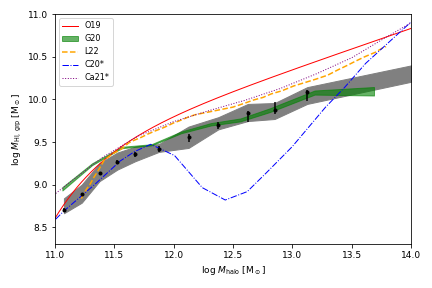

In [86]:
plt.figure()
plt.plot()
tx=np.linspace(11,15,10000)
#plt.plot(tx,np.log10(hihalomodel(10**tx,*popthi)),color='k',linewidth=1, zorder=98, label='G3')
plt.errorbar(binnedhihm.logmh,binnedhihm.ecomhigrp,yerr=[binnedhihm.ecomhigrp_staterrlo,binnedhihm.ecomhigrp_staterrhi],\
             color='k',ls='None',marker='o',markersize=3)
plt.fill_between(binnedhihm.logmh,binnedhihm.ecomhigrp-binnedhihm.ecomhigrp_syserrlo,binnedhihm.ecomhigrp+binnedhihm.ecomhigrp_syserrhi,\
                color='grey')
# Obuljen 2019
obuljen_alpha = 0.48
obuljen_Mmin = 10**(11.18) / 0.7 / fof.getmhoffset(180,337,1,1,6)
obuljen_M0 = 10**9.44 / 0.7 / fof.getmhoffset(180,337,1,1,6)
obuljen_params = (obuljen_M0, obuljen_Mmin, obuljen_alpha)
plt.plot(tx, np.log10(hihalomodel(10**tx,*obuljen_params)), color='red', label='O19',linewidth=1)

# Guo 2020
# show guo et al 2020
guofile = open("TableA1Guo2020.txt", 'r')
guohalomass = []
guohimass = []
guohimasserr = []
guobins = []
for line in guofile:
    if line.startswith('['):
        split = line.split()
        binstart = float(split[0][1:-1])
        binend = float(split[1][:-1])
        guobins.append(binstart)
        guohalomass.append((binstart+binend)/2.)
        guohimass.append(float(split[3]))
        guohimasserr.append(float(split[5]))
guobins.append(binend)
guohimass=np.array(guohimass)
guohimasserr=np.array(guohimasserr)
guohalomass = np.log10(10**np.array(guohalomass)/fof.getmhoffset(200,337,1,1,6))
plt.fill_between(guohalomass,guohimass+guohimasserr,guohimass-guohimasserr,color='green',alpha=0.6,label='G20')

# show Li 22
li = pd.read_csv("Li22xGASS.csv")
li.loc[:,'Mhalo']=np.log10(10**zhang.Mhalo / fof.getmhoffset(200,337,1,1,6))
plt.plot(li.Mhalo,li.Mhi, color='orange', linestyle='dashed', label='L22')

# show chauhan et al 2020
c20data = pd.read_csv("Chauhan2020MedianTotalGroupHI.csv")
c20_logm337 = np.log10(10**c20data.logm200 / fof.getmhoffset(200,337,1,1,6))
c20_himass = np.array(c20data.mhi)
plt.plot(c20_logm337, c20_himass, color='blue', linestyle='-.', label='C20*',linewidth=1)

# show callette 2021
c21data = pd.read_csv("Callette2021relation.csv") # use Delta=333
plt.plot(c21data.logDM, c21data.logMHItot, color='purple', linestyle='dotted', label="Ca21*",linewidth=1)
plt.xlim(11,14)
plt.ylabel(r"log $M_{\rm HI,\, grp}$ [$\rm M_\odot$]")
plt.xlabel(r"log $M_{\rm halo}$ [$\rm M_\odot$]")
plt.ylim(8.3,11.)
plt.tight_layout()
plt.legend(loc='upper left',fontsize=8)
plt.show()